<center>
    <h2 style = "color:green">ISAT 449: Emerging Topics in Applied Data Science</h2>
        <img src="images/mnist.png" width=200; height=200>
    <h2 style = "color:blue">Lab3 -Training a Multilayer Perceptron Model using Scikit-Learn</h2>
    <h3 style = "color:blue">(Image Recognition of the Scikit Learn Handwritten Digits Dataset)</h3>
</center>

<center>
    <h3>by Joshua Brewington

   <h3>Learning Objectives</h3>
        <li>Import and learn about the MNIST dataset and its structure</i>
        <li>Create trianing , validation and test datasets from the MNIST data
        <li>Build a simple but effective Scikit Learn MLPClassifier model for recognizing digits, based on looking at every pixel in the image

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# the first line is telling jupyter to import fetch_openml which helps downloads datasets
# the second line imports train/test splits
# classification report tells us how well the model is performing
# numpy deals with making arrays
# graphs and visuals

When one learns how to program, there's a tradition that the first thing you do is print "Hello World." Just like programming has Hello World,
machine learning has MNIST.

MNIST is a simple computer vision dataset. It consists of images of handwritten digits like these:
        <img src="images/mnist_image.png" width=200; height=200>
It also includes labels for each image, telling us which digit it is. For example, the labels for the above images are 5, 0, 4, and 1.

### Loading Data

Using SciKit-Learns fetch_openml to load MNIST data.

In [2]:
# Load data from https://www.openml.org/d/554
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mnist = fetch_openml(name='mnist_784',version=1, cache=False)

# Import ssl is a line that works for bringing a secure connection to the internet.
# Its a safety feature
# The second line was used to help with security certificates for websites.
# this is loading a dataset from a website OpenML in the variable mnist
# telling to fetch version 1 of the dataset
# cashe=false means the dataset will not be cashed locally.
# Cashe=false means the dataset will be from open source and not on the machine.

### Print the Shape of the data

In [3]:
mnist.data.shape

(70000, 784)

There are 70,000 images and each image has 784 features (each image is 28 x 28 pixels and each pixel represents a feature of an image )

## Preporcessing Data

Each image of the MNIST dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between
0 and 255, representing the pixels intensity, from 0 (white) to 255 (black) corresponding to the grey-value of a pixel.
The above featch_mldata method to load MNIST returns data and target as uint8 which we convert to float32 and int64
respectively.

In [4]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

# minst.data dataset has the handwritten digits, .astype('float32'), changes the data type to 32-bit numbers.
# minst.target has 0-1-2-3-4-5-6-7-8-9 in number form so it is translated into 64-bit integer form.

To avoid big weights that deal with the pixel values from between [0, 255], we scale X down. A commonly used range is [0, 1].

In [5]:
X /= 255.0

In [6]:
X.min(),X.max()

# displays the data, pxel1,2,3 are in the top left of the 28x28 image
# pixel784 is the bottom right.
# The pixels are flattened here.

(pixel1      0.0
 pixel2      0.0
 pixel3      0.0
 pixel4      0.0
 pixel5      0.0
            ... 
 pixel780    0.0
 pixel781    0.0
 pixel782    0.0
 pixel783    0.0
 pixel784    0.0
 Length: 784, dtype: float64,
 pixel1      0.000000
 pixel2      0.000000
 pixel3      0.000000
 pixel4      0.000000
 pixel5      0.000000
               ...   
 pixel780    0.243137
 pixel781    0.000000
 pixel782    0.000000
 pixel783    0.000000
 pixel784    0.000000
 Length: 784, dtype: float64)

Note: initial data is not normalized.

##### Train/Test Split

The MNIST data is already split into a training set (the first 60,000 images) and a test set (the last 10,000 images). Furthermore, the training
set is already shuffled for us! So we can just use python list slicing to generate our datasets from the full set of images.

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# These variables are set to certain indexed values of the dataset.
# [:60000] means index everything from position 0 all the way but not including index  position 60000.
# This is for the training sets for X and y.
# [60000:] is everything from index position 60000 onwards for the testing sets.

#### Print shapes of training and testing sets

In [8]:
X_train.shape, y_train.shape

# the printed X shape has 60,000 images each with a 784 pixel amount.
# the y train shape doesn't have a column in the output because they don't have pixels.
# Instead, the y train has a labeled digit from 0-9. Remember the data type changes.

((60000, 784), (60000,))

### Print a selection of training images and their labels

In [9]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].values.reshape(5,28,28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)
        
# this is a function that plots the first 5 images and their labels from y.
# the for loop iterates through the first 5 images in X and their corresponding labels in y.
# the loop i keeps track of the iteration index, loop variable, (0,1,2,3,4) in this case.
# (img, y) is a tuple unpacking, it unpacks each item in the iterable
# that is made by enumerate(), In each iteration, it assign the current 
# item in the iterable to img and y. img will be the reshaped image, y are the labels.
# enumeratet adds a counter to an iterable. enumerate combines data iterables.
# Here it is combining X and y
# the reshape() operation reshapes each image from a flattened 1D array of pixels into a 2D array for a 28x28 image.
# y displays values
# inside the for loop, it creates a subplot for each iamge using plt.subplot(151 +i)
# the 151 + i is used to determine the position of each subplot in a 1x5 grid of subplots.
# the '151' reprents a 3-digit number where: 1st digit is the number of rows on the grid,
# 2nd digit is the number of columns in the grid, 3rd is the position of the current subplot within the grid.
# the + is a concatination of two data types, the 3 digit number and the i, i is the first 5 images from the for loop.
# instead of i you can treat is as index positions for certain images +0,1,2,3,4...
# plt.imshow(img) shows the image from X
# ticks([]) removes the x and y axis ticks to make the plot cleaner.
# plt.title sets the title of each subplot to be the corresponding value from y.


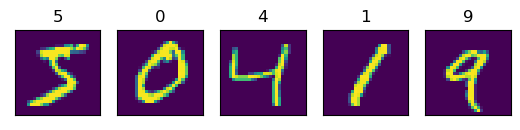

In [10]:
plot_example(X_train, y_train)

# call the plot_example function and set the variables to run the function on as X_train and y_train.

### Is the Training Dataset Balanced?

Let's plot a histogram of the training dastset labels class labels to make sure we have a balanaced dataset, i.e.we want to figure out how often each number is represented in the training dataset This is important when we are trying to eliminate algorithmic bias in our machine learning models.

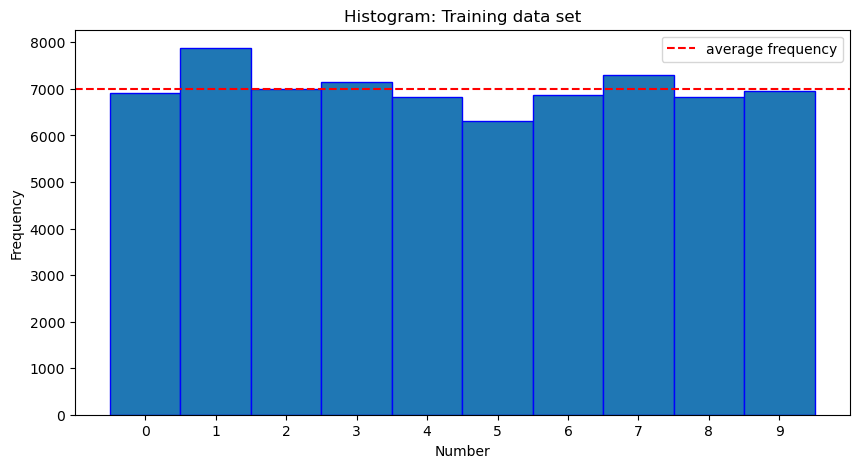

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.hist(y,bins=[0,1,2,3,4,5,6,7,8,9,10], edgecolor="b", histtype="bar",align='left')
ax.set_title('Histogram: Training data set')
ax.set(xlabel='Number', ylabel='Frequency')
ax.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9] );
ax.axhline(y=(y.size/10), label="average frequency",linestyle='dashed', color='r')
ax.legend()

# Creates a plot 'fig', and subplot 'ax'. nrows is the number of rows, ncols is number of columns.
# figsize means 10 units wide, 5 high for the figure.
# fig means to create a figure, ax creates the actual histogram.
# ax.hist creates a histogram plot within the subplot ax. It creates a histogram for y.
# bins sets the bins edges for the values [0,1,2,3...]. The data will be divided
# into 10 bins with intervals from [0,1),[1,2),...
# edgecolor sets the color to blue, histtype sets it to a barchart, align left means out the bars on the left bin edges.
# ax.xaxis.set_ticks sets custom tick locations for the x-axis. It says where the tick marks should be placed.
# ax.axhline adds a horizontal line to the ax plot.
# The y=(y.size/10) where the redline should be placed, it is set to average frequency which is the total number of data points y.size/10.
# ax.legend adds a legend for the average frequency label.

We can see the number of examples for each number to detect is not even distributed. There are more 1, 3 and 7 in the dataset.

## Build Neural Network with Scitkit Learn MultiLayer Perceptron Classifier

Let's build a simple, fully connected neural network with three hidden layers with the following parameters:

### The Model using a Multilayer Perceptron Classifier

#### Build the model with 3 hidden layers as follows:

<li> hidden layer =256 neurons
<li> hidden layer = 128 neurons
<li> hidden layer = 32 neurons</li>

#### also, use these parameters

<li> solver ='adam'
<li> learning_rate_init= 0.001
<li> tol=1e-2
<li> max_iter= 500
<li> verbose = True
<li> random_state=1</li>

You can use the default values for the rest of the parameters

Input layer has 784 dimensions (28x28), and the output layer 10 neurons, representing digits 0 - 9. The MLPClassifier implements a multi-layer
perceptron (MLP) algorithm that trains using Backpropagation. MLP trains on two arrays: array X of size (n_samples, n_features), which holds
the training samples represented as floating point feature vectors; and array y of size (n_samples,), which holds the target values (class labels)
for the training samples:

In [12]:
from sklearn.neural_network import MLPClassifier

#TO-DO Instantiate the model and name it as below
mlp_mnist_model =  MLPClassifier(solver='adam' ,hidden_layer_sizes=(256, 128, 32), learning_rate_init= 0.001,
                   random_state=1, max_iter=500, verbose=True, tol=1.0e-2)

# The import MLPClassifier is a multi-layer perceptron
# the solver adam is adaptive moment estimation and it optimizes during training of the network.
# the learning_rate_init sets the initial learning rate for the optimization. It controls how quickly the model adapts to traning data.
# random state is a random seed
# max_iter sets the max number of iterations or epochs for the training.
# verbose=True allows us to see the training progress such as progess updates, loss values, performance metrics, additional output.
# This helps monitor training.
# tol=1.0e-2 is a tolerance for convergence. Training stops when the change in the loss function (error) between iterations is smaller than this.

In [13]:
mlp_mnist_model.fit(X_train, y_train)

# This sets our training sets to the model made above.
# It runs the handwritten dataset through the hidden layers.

Iteration 1, loss = 0.34110846
Iteration 2, loss = 0.12689621
Iteration 3, loss = 0.08622532
Iteration 4, loss = 0.06181403
Iteration 5, loss = 0.04469420
Iteration 6, loss = 0.03410506
Iteration 7, loss = 0.02856108
Iteration 8, loss = 0.02109429
Iteration 9, loss = 0.01839320
Iteration 10, loss = 0.01591000
Iteration 11, loss = 0.01278140
Iteration 12, loss = 0.01484089
Iteration 13, loss = 0.01096972
Iteration 14, loss = 0.01185615
Iteration 15, loss = 0.01366165
Iteration 16, loss = 0.00904404
Iteration 17, loss = 0.00931641
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(hidden_layer_sizes=(256, 128, 32), max_iter=500, random_state=1,
              tol=0.01, verbose=True)

In [14]:
mlp_mnist_model.out_activation_

# This states the type of activation function that was automatically chosen for training.

'softmax'

In [15]:
mlp_mnist_model.n_layers_

# This displays the number of layers in total count of input + hidden + output
# If it returns a '5', it means that the neural network has 3 hidden layers + input/output

5

In [16]:
mlp_mnist_model.n_outputs_

# This means the neural network has 10 outputs, which correlate to the digit labels in y.

10

In [17]:
mlp_mnist_model.n_iter_

# This displays the number of epochs

17

### Model Evaluation and Performance

In [18]:
mlp_mnist_model.score(X_test, y_test)

# This checks the accuracy score of the neural network with the testing sets.
# It displays a number from 0-1.

0.9797

In [19]:
from sklearn.metrics import accuracy_score

# import accuracy score

In [20]:
y_pred = mlp_mnist_model.predict(X_test)

# here y pred is set to the model we are asking the machine to make a prediction of the X_test

In [21]:
accuracy_score(y_test,y_pred)

# checks the accuracy by setting the two variables as the ratio of correctly predicted labels to the total number of labels.

0.9797

An accuracy of about 98% for a network with only two hidden layers is not too bad.

Let's take a look at some predictions that **went wrong:**

In [22]:
error_mask = y_pred !=y_test

# creates a booelan mask (array of True and False values) that show when a prediction
# made by y_pred is different from the true labels y_test.
# print True when there is a prediction error for a data point.
# print False when the prediction is correct.

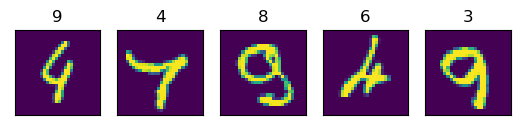

In [23]:
plot_example(X_test[error_mask], y_pred[error_mask])

# This is filtering the prediction errors from the dataset and their corresponding y labels.
# It runs it through the error_mask variable

In [24]:
loss_values = mlp_mnist_model.loss_curve_

# calls the neural network model and adds the loss_curve_ attribute.
# loss_values allows us to visually show the epochs behavior.

In [25]:
print('loss values are {}'.format(loss_values))
# These are the epochs that failed to predict from the training sets.

loss values are [0.34110846042951276, 0.12689620770847554, 0.08622531972503986, 0.06181402712802281, 0.04469420270366452, 0.034105055012104216, 0.028561075594589428, 0.02109429404601666, 0.018393198658387407, 0.01590999714511759, 0.012781404164148228, 0.014840889651868597, 0.01096971902615008, 0.011856150622599215, 0.01366164899617323, 0.009044042135279871, 0.009316408125944113]


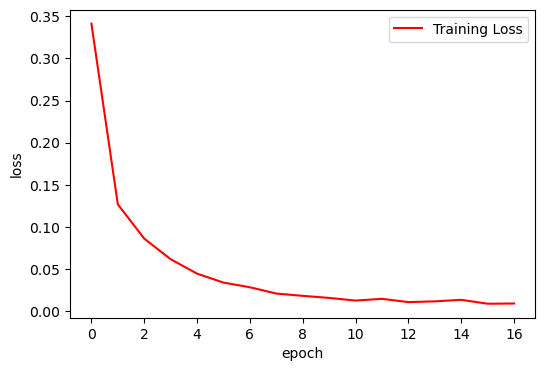

In [26]:
# TO-DO Plot the loss_values (Label each axis, put in a legend and put a title on plot.)
fig=plt.figure(figsize=(6,4))
plt.plot(loss_values, color="red", label="Training Loss")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

# Plotting the loss curve.

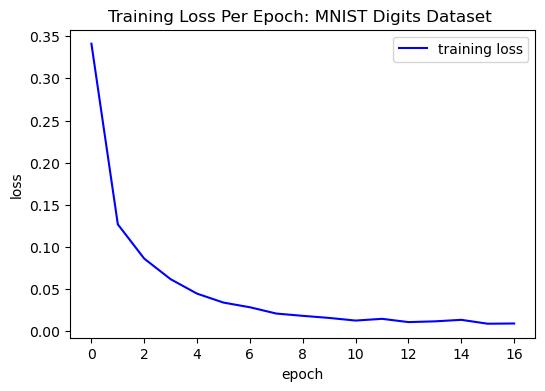

In [27]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
plt.plot(loss_values, color="blue", label = 'training loss')
plt.xlabel('epoch')
plt.ylabel('loss');
#legend
plt.legend(loc='upper right')
#title
plt.title('Training Loss Per Epoch: MNIST Digits Dataset ')
#show plot
plt.show()

#### Classification Report

In [28]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.96      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#### Confusion Matrix

A further statistic is the confusion matrix that shows the errors that the classifier made during training.

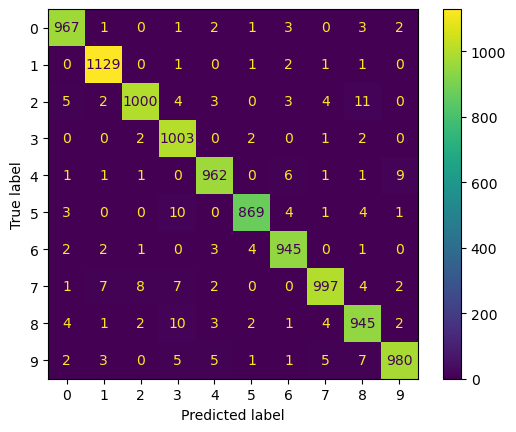

In [29]:
#TO-DO: print a pretty confusion matrix (see previous notebooks)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=range(10))
disp.plot()

plt.show()

<center>
    <h2 style = "color:red">Exercises<h2>
    </center>   
<h3 style = "color:green">Answer the questions below in your notebook. Submit your completed Jupyter Notebook. Please Zip it with any other files or folders you have (your images should be in a separate images folder).</h3>

### Exercise 1 (5 points)

<li> Based on the confusion matrix, which digit was hardest for the model to classify? Justify your answer!

Digit 0: 967/980 = 0.9867

Digit 1: 1129/1135 = 0.9947

Digit 2: 1000/1013 = 0.9871

Digit 3: 1003/1010 = 0.993

Digit 4: 962/982 = 0.9796

Digit 5: 869/892 = 0.9742

Digit 6: 945/958 = 0.9864

Digit 7: 997/1028 = 0.9698

Digit 8: 945/974 = 0.9702

Digit 9: 980/1004 = 0.9760

The hardest digit to classify was digit 7 because it had the lowest accuracy.

### Exercise 2 (10 points)

<li>Based on the output of your classification report, out of all the times digit 7 should have been predicted, what percentage of times was it correctly predicted? (HINT: You may need to research the meaning and difference between precision, recall and f1-score)
<li>Do a simple calculation (do it here!) to justify your answer. It compares to what metric in the classification report?

Precision for digit 7 = True Positives / (True Positives + False Positives)

= 1028 / (1028 + (total number of times 7 was incorrectly predicted))

Precision = 1028/(1028+30) = **0.9712**

This precision value correlates with the precision value under class 7 in the classification report which is **0.98**.

### Exercise 3 (10 points)

<il>Train the model using the 'sgd' optimizer (scikit learn calls it a solver). Does the accuracy improve? Comment (one line!) as to what you
think is contributing to the change in performance of the model.


In [30]:
mlp_mnist_model =  MLPClassifier(solver='sgd' ,hidden_layer_sizes=(256, 128, 32), learning_rate_init= 0.001,
                   random_state=1, max_iter=500, verbose=True, tol=1.0e-2)

In [31]:
mlp_mnist_model.fit(X_train,y_train)

Iteration 1, loss = 1.70057155
Iteration 2, loss = 0.65671763
Iteration 3, loss = 0.43655073
Iteration 4, loss = 0.36794087
Iteration 5, loss = 0.33161744
Iteration 6, loss = 0.30703774
Iteration 7, loss = 0.28804398
Iteration 8, loss = 0.27250223
Iteration 9, loss = 0.25887135
Iteration 10, loss = 0.24714255
Iteration 11, loss = 0.23634392
Iteration 12, loss = 0.22664972
Iteration 13, loss = 0.21761617
Iteration 14, loss = 0.20970263
Iteration 15, loss = 0.20201468
Iteration 16, loss = 0.19497689
Iteration 17, loss = 0.18807919
Iteration 18, loss = 0.18187857
Iteration 19, loss = 0.17621118
Iteration 20, loss = 0.17050658
Iteration 21, loss = 0.16533377
Iteration 22, loss = 0.16050391
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(hidden_layer_sizes=(256, 128, 32), max_iter=500, random_state=1,
              solver='sgd', tol=0.01, verbose=True)

In [32]:
y_pred = mlp_mnist_model.predict(X_test)
accuracy_scores = accuracy_score(y_test, y_pred)
print("Accuracy Score (accuracy_score):", accuracy_scores)

Accuracy Score (accuracy_score): 0.9536


The accuracy score decreased because we used a different optimizer in 'sgd'.

### Exercise 4 (10 points)

<li>Feed the model a single image from the test set to classify and have the model return the class membership probabilities and print them
out for this single image classification. Note you have to reshape the imgage to 28 x 28 before you try and display it! Also, you can use the
last model you trained if your accuracy is > 95%
<li>NOTE:For this exercise, feed the model the image: X_test[54:55]

In [33]:
#TO DO -class membership probabilities

index = 54
predicted_digit = y_pred[index]

prob = mlp_mnist_model.predict_proba(X_test[54:55])
print(prob)
#np.argmax(prob)
#print('The predicted digit is :', predicted_digit)

[[2.70596963e-04 6.75224086e-06 3.05440473e-02 1.02911798e-04
  1.19859793e-04 7.83543750e-05 9.68063118e-01 4.68044026e-07
  8.13713156e-04 1.77873542e-07]]


#### Plot Image

NOTE: The array has to be turned into a numpy array before you reshape it

The corresponding predicted image is:


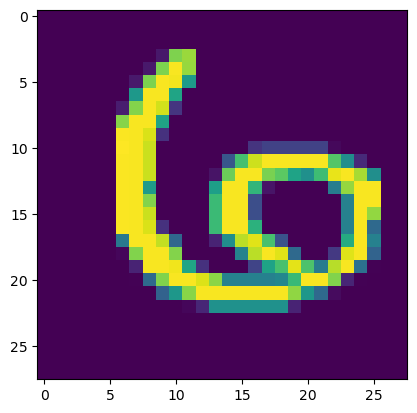

In [34]:
# TO DO - Plot Image
print('The corresponding predicted image is:')
plt.imshow(X_test.iloc[index].values.reshape(28, 28))
plt.show()

In [35]:
# TO DO - Print the value from y_test to compare with the image

print('The true digit from y_test is :', y_test.iloc[index])  # Use iloc to access by position

The true digit from y_test is : 6
